# Export UHI intensity
- This script is used to export UHI insensity, urban and rural temperature.
- Simulation: CNTL, TranAlbe

In [ ]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
home_path = '/gws/ssde/j25a/duicv/yuansun/'
project_path = f'{home_path}0_wrf-cstm_GM-HK/'
var_list = ['TSA', 'TG']

In [ ]:
ds_mask_hk = xr.open_dataset(f'{project_path}HK/mask/mask_HK_lat_lon.nc')
ds_mask_hk_pct_urban = ds_mask_hk['PCT_URBAN']  # values: 0-1
ds_mask_hk_pct_rural = 1 - ds_mask_hk['PCT_URBAN'] # values: 0-1
region='HK'

In [17]:
scenario = 'cntl'
#scenario = 'tran_albe'
wrfout_path = f'{project_path}runs/TranUrbAlb_{region}/runs/d04_{scenario}/archive_ctsm/lnd/'
wrfout_path_files = os.listdir(wrfout_path)
#nc_files = [f for f in wrfout_path_files if f.endswith('.nc') and 'cntl_albe1.clm2.h0.' in f]
nc_files = [f for f in wrfout_path_files if f.endswith('.nc')  and '.clm2.h0.' in f]
total_urban_results = []
total_rural_results = []
total_uhi_results = []
for files in nc_files:
    ds = xr.open_dataset(f'{wrfout_path}{files}')
    ds = ds.assign_coords(time=ds['time'].dt.round("h"))
    urban_average_list = []
    rural_average_list = []
    uhi_average_list = []
    for var in var_list:
        ds_var_urban = ds[f'{var}_U'].where(ds_mask_hk['mask'] == 1)
        ds_var_rural = ds[f'{var}_R'].where(ds_mask_hk['mask'] == 1)
        ds_var_urban_average = (ds_var_urban * ds_mask_hk_pct_urban).sum(dim=['lat', 'lon'], skipna=True) / ds_mask_hk_pct_urban.sum(dim=['lat', 'lon'], skipna=True)-273.15
        ds_var_rural_average = (ds_var_rural * ds_mask_hk_pct_rural).sum(dim=['lat', 'lon'], skipna=True) / ds_mask_hk_pct_rural.sum(dim=['lat', 'lon'], skipna=True)-273.15
        ds_var_uhi_average = ds_var_urban_average - ds_var_rural_average
        df_var_urban_average = ds_var_urban_average.to_dataframe(var).reset_index()
        df_var_rural_average = ds_var_rural_average.to_dataframe(var).reset_index()
        df_var_uhi_average = ds_var_uhi_average.to_dataframe(var).reset_index()
        urban_average_list.append(df_var_urban_average.rename(columns={var: f'{var}_urban'}))
        rural_average_list.append(df_var_rural_average.rename(columns={var: f'{var}_rural'}))
        uhi_average_list.append(df_var_uhi_average.rename(columns={var: f'{var}_uhi'}))
    df_var_urban_average = pd.merge(urban_average_list[0], urban_average_list[1], on='time', how='inner')
    df_var_rural_average = pd.merge(rural_average_list[0], rural_average_list[1], on='time', how='inner')
    df_var_uhi_average = pd.merge(uhi_average_list[0], uhi_average_list[1], on='time', how='inner')
    total_urban_results.append(df_var_urban_average)
    total_rural_results.append(df_var_rural_average)
    total_uhi_results.append(df_var_uhi_average)
df_urban_all = pd.concat(total_urban_results, axis=0, ignore_index=True)
df_rural_all = pd.concat(total_rural_results, axis=0, ignore_index=True)
df_uhi_all = pd.concat(total_uhi_results, axis=0, ignore_index=True)
df_all = df_urban_all.merge(df_rural_all, on='time', how='inner').merge(df_uhi_all, on='time', how='inner')
output_filename = f'./data_for_figure/{region}_tmax_{scenario}_urban_rural.csv'
df_all['time'] = pd.to_datetime(df_all['time'])
df_all_clean = df_all.sort_values(by='time')
df_all_clean.to_csv(output_filename, index=False)
df_all_clean

,time,TSA_urban,TG_urban,TSA_rural,TG_rural,TSA_uhi,TG_uhi
0,2034-12-25 01:00:00,17.254911,17.243349,18.575551,17.367573,-1.320639,-0.124224
1,2034-12-25 02:00:00,20.072208,22.635449,20.277115,19.164834,-0.204907,3.470615
2,2034-12-25 03:00:00,22.394302,27.483924,21.924120,21.279491,0.470182,6.204433
3,2034-12-25 04:00:00,24.341959,31.272522,23.306664,23.334504,1.035296,7.938018
4,2034-12-25 05:00:00,25.725909,33.679868,24.287652,24.924053,1.438257,8.755815
...,...,...,...,...,...,...,...
39595,2039-12-29 20:00:00,19.996728,19.477529,19.031087,19.331718,0.965642,0.145810
39596,2039-12-29 21:00:00,19.801344,19.256436,18.898272,19.217164,0.903072,0.039271
39597,2039-12-29 22:00:00,19.607753,19.043431,18.761341,19.099154,0.846412,-0.055723
39598,2039-12-29 23:00:00,19.419317,18.837113,18.631405,18.979037,0.787912,-0.141924


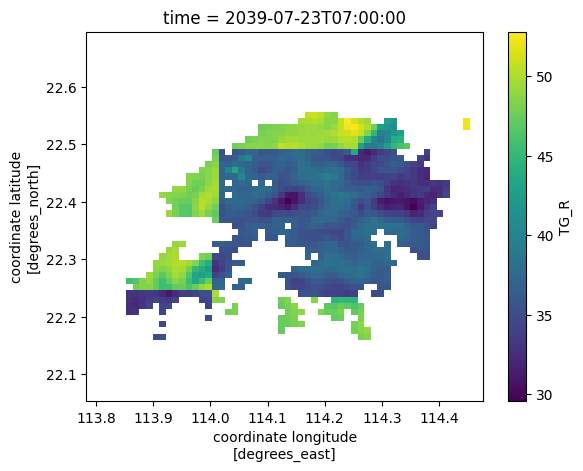

In [ ]:
(ds_var_rural[6]-273.15).plot()